<h1 style="font-size:30px;">Introduction to Object Detection using YOLOv8</h1>

In the previous modules, we have fine-tuned and trained some popular classification models.

In this notebook, we shall explore the pre-trained object detection models offerered by YOLOv8.


## Table of Contents

* [1 What is Object Detection](#1-What-is-Object-Detection?)
* [2 What is YOLOv8?](#2-What-is-YOLOv8?)
* [3 Inference across YOLOv8 pre-trained models](#3-Inference-across-YOLOv8-pre-trained-models)
* [4 Visualizations](#4-Visualizations)
* [5 Fine-Tuning YOLOv8 For Small Object Detection of Airplanes in Aerial Imageryn](#5-fine-tuning-yolov8-for-small-object-detection-of-airplanes-in-aerial-imageryn)
* [6 Conclusions](#conclusions)

## 1 What is Object Detection?

Unlike classification, object detection, on the other hand, refers to the task of identifying and localizing objects within an image. The goal of object detection is not only to predict the class label of an object but also to identify the object's location within the image.

For instance, observe the example image shown below. Apart from classifying the two objects as **person** (on the left) and **dog** (on the right), the object detection model also outputs the location (i.e., the coordinates) of where these objects are located.

Generally, The model will predict 3 things:
1. The **Location** or Coordinates of the object.
2. The **class label** associated with the object for example the Person or the Dog.
3. The **confidence score** which is a number between 0 and 1 that signifies how well the model is able to identify the object.


<img src="https://opencv.org/wp-content/uploads/2023/01/object_detection.png" width="800">

## 2 What is YOLOv8?

[Ultralytics](https://ultralytics.com) [YOLOv8](https://github.com/ultralytics/ultralytics) is a cutting-edge, state-of-the-art (SOTA) model that builds upon the success of previous YOLO versions and introduces new features and improvements to further boost performance and flexibility. YOLOv8 is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and tracking, instance segmentation, image classification and pose estimation tasks.

Five YOLOv8 models have been released that can be used in FP32, FP16, and INT8 precisions:
- **nano** (`n`)
- **small** (`s`)
- **medium** (`m`)
- **large** (`l`)
- **extra large** (`x`)

YOLOv8 [Detect](https://docs.ultralytics.com/tasks/detect), [Segment](https://docs.ultralytics.com/tasks/segment) and [Pose](https://docs.ultralytics.com/tasks/pose) models pretrained on the [COCO](https://docs.ultralytics.com/datasets/detect/coco) dataset, as well as YOLOv8 [Classify](https://docs.ultralytics.com/tasks/classify) models pretrained on the [ImageNet](https://docs.ultralytics.com/datasets/classify/imagenet) dataset. [Track](https://docs.ultralytics.com/modes/track) mode is available for all Detect, Segment and Pose models.


The table below shows the performance metrics (**mean Average Precision** abbreviated as **mAP**) across the various models on the MS-COCO 2017 validation data  and latency benchmarked on **Amazon EC2 P4d (A100)**.


| Model                                                                                | size<br><sup>(pixels) | mAP<sup>val<br>50-95 | Speed<br><sup>CPU ONNX<br>(ms) | Speed<br><sup>A100 TensorRT<br>(ms) | params<br><sup>(M) | FLOPs<br><sup>(B) |
| ------------------------------------------------------------------------------------ | --------------------- | -------------------- | ------------------------------ | ----------------------------------- | ------------------ | ----------------- |
| [YOLOv8n](https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8n.pt) | 640                   | 37.3                 | 80.4                           | 0.99                                | 3.2                | 8.7               |
| [YOLOv8s](https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8s.pt) | 640                   | 44.9                 | 128.4                          | 1.20                                | 11.2               | 28.6              |
| [YOLOv8m](https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8m.pt) | 640                   | 50.2                 | 234.7                          | 1.83                                | 25.9               | 78.9              |
| [YOLOv8l](https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8l.pt) | 640                   | 52.9                 | 375.2                          | 2.39                                | 43.7               | 165.2             |
| [YOLOv8x](https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8x.pt) | 640                   | 53.9                 | 479.1                          | 3.53                                | 68.2               | 257.8             |

#### **Let's start by installing the dependencies**

In [1]:
# install required library
#!pip install -U torch ultralytics
!pip install -U ultralytics

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.1 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 77.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 KB 84.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 31.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 35.4 MB/s eta 0:00:0000:0100:01


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.66 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
Setup complete ✅ (30 CPUs, 222.2 GB RAM, 25.4/1356.7 GB disk)


We begin by importing the necessary dependencies.

**NOTE:** After running this cell, the runtime may need to be restarted. After that is done, you can continue with the other cells.

For restarting the runtime, follow this:



1.   Runtime -> Restart Runtime
2.   (or) just press *Ctrl + M*

In [1]:
import numpy
numpy.__version__

'1.26.1'

In [2]:
#!pip install numpy==1.26.1

In [3]:
from zipfile import ZipFile
from matplotlib.image import imread
from ultralytics import YOLO
from matplotlib.image import imread

import os
import random
import requests
import zipfile
import matplotlib.pyplot as plt
import cv2
import glob
import torch
import matplotlib.patches as patches
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/ubuntu/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### 3.1 Load Sample Images

We have already provided some sample images that need to be downloaded first. The `download_and_unzip` exactly does this.

In [4]:
def download_and_unzip(url, save_path):

    print('Downloading and extracting assets...', end='')
    file = requests.get(url)
    open(save_path, 'wb').write(file.content)

    try:
        with ZipFile(save_path) as z:
            z.extractall('./') # Unzip where downloaded.
            print('Done')
    except:
        print('Invalid file')

Now that we have the utilities for downloading and unzipping let us specify the URL and download and extract the required file.

We also maintain a list containing the file paths for the samples.

In [5]:
# URL and Name of our test image folder
test_images_url = 'https://www.dropbox.com/scl/fo/mkef4p5h2klyqv1irqtuq/AHzZKEW5n7-rdJEuEuubQsk?rlkey=3ag81ucrg5b86ok8cy7jfngos&st=00o4rjyg&dl=1'
test_images_zip = 'object-detection-test-images.zip'

if not os.path.exists('test_images'):
    download_and_unzip(test_images_url, test_images_zip)
    os.remove(test_images_zip)

In [6]:
folder_name = 'test_images'
# Load complete image file paths in a list
image_paths = os.listdir(folder_name)
image_paths = [os.path.join(folder_name,  img) for img in image_paths]
image_paths.sort()

In [8]:
image_paths

['test_images/.ipynb_checkpoints',
 'test_images/test_image_1.jpg',
 'test_images/test_image_2.jpg',
 'test_images/test_image_3.jpg',
 'test_images/test_image_4.jpg']

In [9]:
image_paths = image_paths[1:]
image_paths

['test_images/test_image_1.jpg',
 'test_images/test_image_2.jpg',
 'test_images/test_image_3.jpg',
 'test_images/test_image_4.jpg']

Let us visualize our sample images by plotting them.

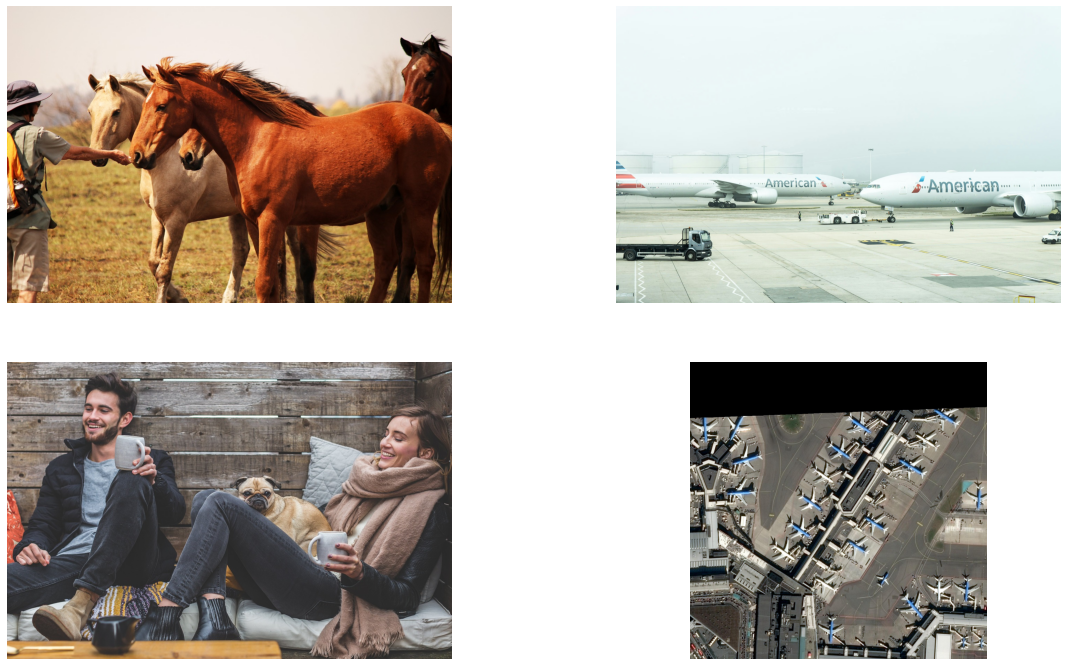

In [11]:
images = []
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

for idx, axis in enumerate(ax.flat):
    image_array = cv2.imread(image_paths[idx])[..., ::-1]
    axis.imshow(image_array)
    axis.axis('off')

plt.show(block=False)

### 3.2 Perform Inference

The function `run_inference` takes in a list of image files, the model, the name of the model (`yolov8n`, `yolov8s`, `yolov8m`), and the device. It saves the output predictions in the corresponding folder defined by the **model name** with the prefix `inference_results_`.

The model predictions are obtained by calling the `predict` function, which accepts the image file path, the confidence (`conf`) threshold, and the `iou` threshold (for NMS).

The output is a list of `Results` instances, where each instance contains the prediction results for a single image.

Instead of saving the images, if you want to obtain the predicted bounding boxes, confidence scores, and class labels, you need to access the attributes of the `Results` instance for each image. The `Results` class has the following attributes:
* `boxes.xyxy`: A NumPy array of the absolute box coordinates in `[xmin, ymin, xmax, ymax]` format.
* `boxes.conf`: A NumPy array of confidence scores.
* `boxes.cls`: A NumPy array of predicted class labels.

An example of the usage to obtain the prediction data is shown below:
```python
bbox_coords = out[0].boxes.xyxy
conf_scores = out[0].boxes.conf
pred_labels = out[0].boxes.cls
```

**Note:** In the above syntax, the index `0` represents performing single image inference at a time.



## Load the YOLO Model

In [12]:
model = YOLO()

## Perform Prediction

In [13]:
result = model.predict(image_paths[0])


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_1.jpg: 448x640 1 person, 3 horses, 169.5ms
Speed: 3.7ms preprocess, 169.5ms inference, 32.6ms postprocess per image at shape (1, 3, 448, 640)


## Save the Outputs

In [14]:
result = model.predict(image_paths[0], save=True)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_1.jpg: 448x640 1 person, 3 horses, 14.6ms
Speed: 3.9ms preprocess, 14.6ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict


## Changing Confidence Score

In [15]:
result = model.predict(image_paths[0], save=True, conf=0.01)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_1.jpg: 448x640 4 persons, 10 horses, 15.2ms
Speed: 4.0ms preprocess, 15.2ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict


In [19]:
result = model.predict(image_paths[0], save=True, conf=0.2)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_1.jpg: 448x640 1 person, 4 horses, 14.8ms
Speed: 3.7ms preprocess, 14.8ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict


## Getting the detections

In [20]:
print(result)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant'

In [21]:
print(result[0].boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([17.,  0., 17., 17., 17.], device='cuda:0')
conf: tensor([0.9285, 0.9274, 0.5588, 0.4193, 0.2124], device='cuda:0')
data: tensor([[3.5270e+02, 1.5406e+02, 1.2800e+03, 8.4989e+02, 9.2850e-01, 1.7000e+01],
        [4.3211e-01, 2.1030e+02, 3.6068e+02, 8.4203e+02, 9.2737e-01, 0.0000e+00],
        [1.1281e+03, 7.8377e+01, 1.2790e+03, 3.4130e+02, 5.5877e-01, 1.7000e+01],
        [2.2889e+02, 1.9360e+02, 7.1319e+02, 8.4328e+02, 4.1933e-01, 1.7000e+01],
        [1.2226e+03, 4.7039e+02, 1.2795e+03, 8.4253e+02, 2.1240e-01, 1.7000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (853, 1280)
shape: torch.Size([5, 6])
xywh: tensor([[ 816.3503,  501.9775,  927.2994,  695.8313],
        [ 180.5580,  526.1612,  360.2519,  631.7286],
        [1203.5437,  209.8391,  150.8441,  262.9239],
        [ 471.0403,  518.4442,  484.2934,  649.6793],
        [1251.0317,  656.4614,   56.8463,  372.1337]], device='cuda:0')
xywhn: tens

In [22]:
from torchvision.io import read_image
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import draw_bounding_boxes, make_grid

In [25]:
%pwd

'/home/ubuntu/opencv-dl-application-m2'

In [26]:
image_path = "./runs/detect/predict/test_image_1.jpg"
image = read_image(str(image_path))
print(image.shape, type(image))

torch.Size([3, 853, 1280]) <class 'torch.Tensor'>


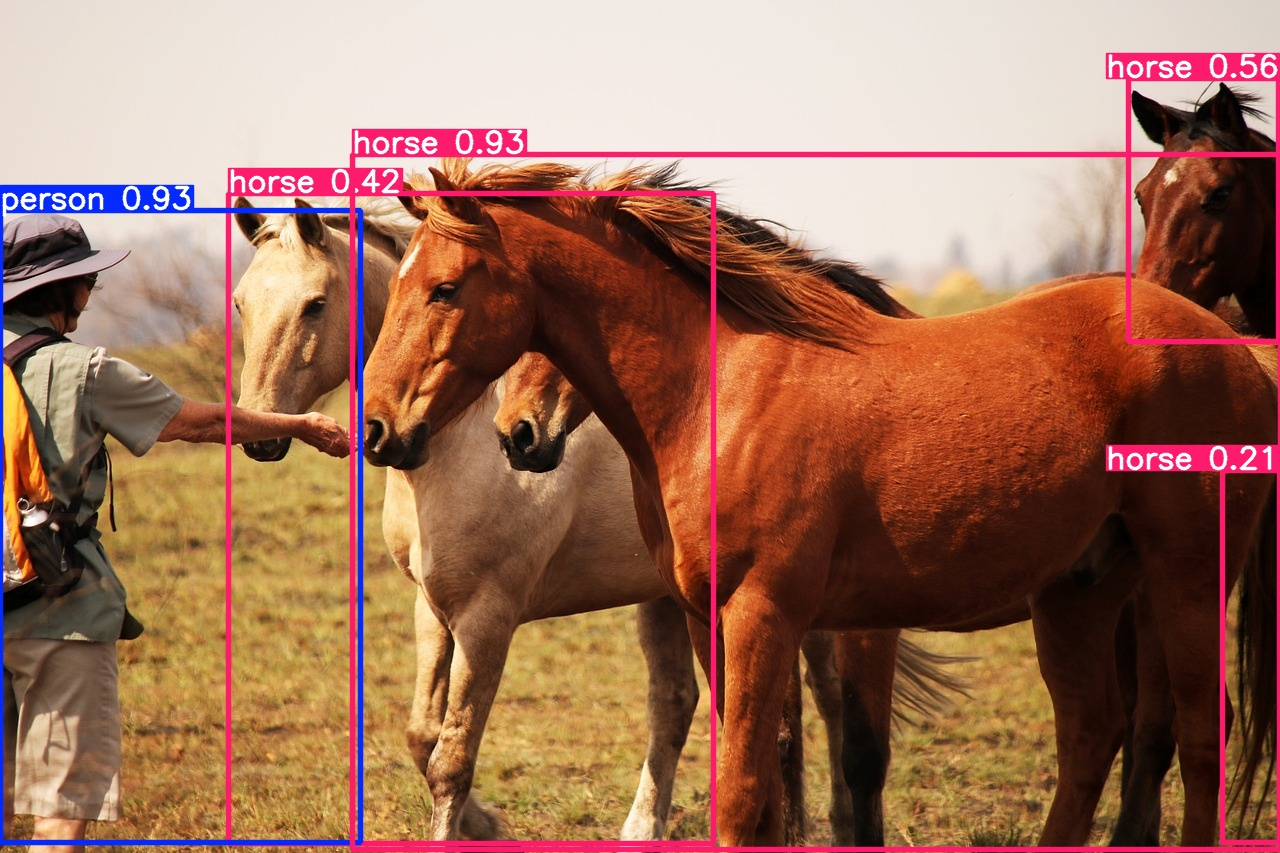

In [28]:
to_pil_image(image)

In [29]:
result = model.predict(image_paths[1], save=True)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_2.jpg: 448x640 1 person, 2 airplanes, 3 trucks, 14.3ms
Speed: 3.6ms preprocess, 14.3ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict


In [30]:
model2 = YOLO("yolov8m.pt")

In [31]:
result2 = model2.predict(image_paths[1], save=True)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_2.jpg: 448x640 2 persons, 1 car, 2 airplanes, 3 trucks, 103.6ms
Speed: 4.0ms preprocess, 103.6ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict-2


In [35]:
result3 = model.predict(image_paths[2], save=True)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_3.jpg: 448x640 2 persons, 1 handbag, 1 cup, 1 cell phone, 15.6ms
Speed: 4.0ms preprocess, 15.6ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict


In [49]:
result4 = model2.predict(image_paths[3], save=True, conf=0.01)


image 1/1 /home/ubuntu/opencv-dl-application-m2/test_images/test_image_4.jpg: 640x640 2 persons, 19 airplanes, 1 traffic light, 1 bottle, 1 chair, 10 clocks, 11.7ms
Speed: 5.2ms preprocess, 11.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/ubuntu/opencv-dl-application-m2/runs/detect/predict-2
